# EDA of Vitamin Deficiency Dataset

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/COPY_vitamin_deficiency_disease_dataset_20260123.csv")

# Display the first few rows of the dataset
print("Dataset Information:")
print(f"Shape: {df.shape}")
print(f"Features: {len(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

Dataset Information:
Shape: (4000, 34)
Features: 34

First 5 rows:
   age  gender   bmi smoking_status alcohol_consumption exercise_level  \
0   79    Male  24.8         Former                 NaN         Active   
1   77  Female  39.9         Former            Moderate          Light   
2   24    Male  26.4         Former               Heavy       Moderate   
3   69    Male  23.1          Never               Heavy       Moderate   
4   63    Male  29.6          Never                 NaN       Moderate   

    diet_type sun_exposure income_level latitude_region  ...  \
0  Vegetarian         High         High             Mid  ...   
1    Omnivore          Low          Low             Low  ...   
2    Omnivore          Low         High            High  ...   
3  Vegetarian         High          Low             Low  ...   
4  Vegetarian     Moderate         High             Low  ...   

   has_night_blindness  has_fatigue  has_bleeding_gums  has_bone_pain  \
0                    0        

In [20]:
# Exploring the dataset structure
print("Dataset Overview:")
print("=" * 50)
print(f"Total samples: {len(df)}")

# Check for missing values
print(f"\nMissing values: \n{df.isnull().sum()}")

# Check for duplicates
print("-" * 50)
print(f"Duplicate entries: {df.duplicated().sum()}")

# Basic info of the dataset
print("\nBasic Statistics:")
print("=" * 50)
print(df.info())

# Different diseases in the dataset
print("\nDisease Counts:")
print("=" * 50)
print(df['disease_diagnosis'].value_counts())

Dataset Overview:
Total samples: 4000

Missing values: 
age                             0
gender                          0
bmi                             0
smoking_status                  0
alcohol_consumption          1278
exercise_level                  0
diet_type                       0
sun_exposure                    0
income_level                    0
latitude_region                 0
vitamin_a_percent_rda           0
vitamin_c_percent_rda           0
vitamin_d_percent_rda           0
vitamin_e_percent_rda           0
vitamin_b12_percent_rda         0
folate_percent_rda              0
calcium_percent_rda             0
iron_percent_rda                0
hemoglobin_g_dl                 0
serum_vitamin_d_ng_ml           0
serum_vitamin_b12_pg_ml         0
serum_folate_ng_ml              0
symptoms_count                  0
symptoms_list                1328
has_night_blindness             0
has_fatigue                     0
has_bleeding_gums               0
has_bone_pain             

# Summary after EDA

Upon analysis it appears that both the "alcohol_consumption" and "symptoms_list" features have null values. However, it appears that both features have entries that are non-null but are mistakingly being picked up as null ("None").

In [ ]:
# Correcting mistaken missing value in 'alcohol_consumption' column
df['alcohol_consumption'] = df['alcohol_consumption'].fillna("No Consumption")

# Verify that there are no more missing values in 'alcohol_consumption'
print("Missing values in 'alcohol_consumption' after imputation:")
print(df['alcohol_consumption'].isnull().sum())

Missing values in 'alcohol_consumption' after imputation:
0


In [23]:
# Correcting mistaken missing value in 'symptom_list' column
df['symptoms_list'] = df['symptoms_list'].fillna("No Symptoms")

# Verify that there are no more missing values in 'symptom_list'
print("Missing values in 'symptoms_list' after imputation:")
print(df['symptoms_list'].isnull().sum())

Missing values in 'symptoms_list' after imputation:
0


In [ ]:
# Checking for missing values again after corrections
print(f"\nMissing values: \n{df.isnull().sum()}")


Missing values: 
age                          0
gender                       0
bmi                          0
smoking_status               0
alcohol_consumption          0
exercise_level               0
diet_type                    0
sun_exposure                 0
income_level                 0
latitude_region              0
vitamin_a_percent_rda        0
vitamin_c_percent_rda        0
vitamin_d_percent_rda        0
vitamin_e_percent_rda        0
vitamin_b12_percent_rda      0
folate_percent_rda           0
calcium_percent_rda          0
iron_percent_rda             0
hemoglobin_g_dl              0
serum_vitamin_d_ng_ml        0
serum_vitamin_b12_pg_ml      0
serum_folate_ng_ml           0
symptoms_count               0
symptoms_list                0
has_night_blindness          0
has_fatigue                  0
has_bleeding_gums            0
has_bone_pain                0
has_muscle_weakness          0
has_numbness_tingling        0
has_memory_problems          0
has_pale_skin        

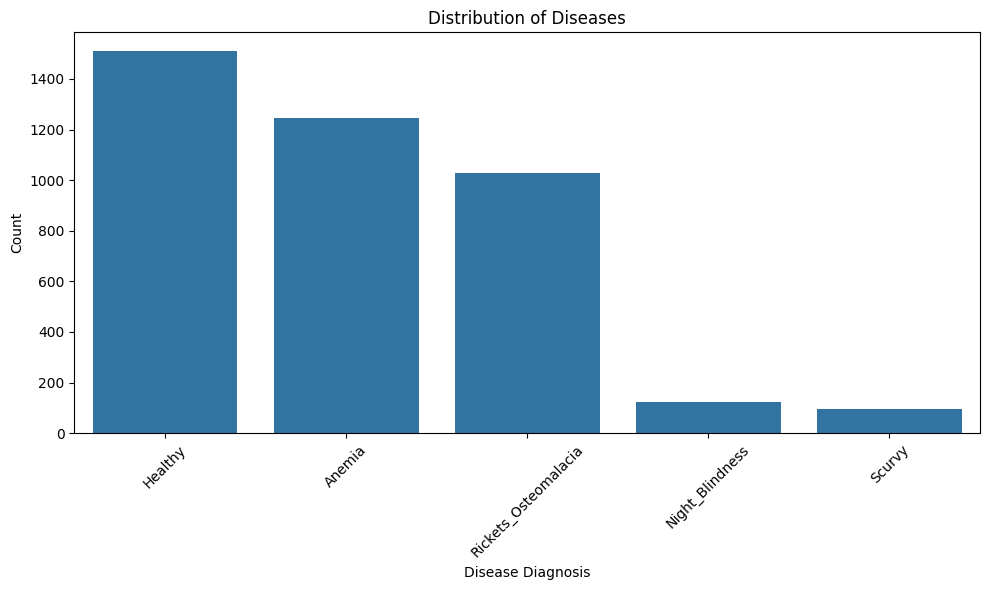

In [25]:
# Visualize the distribution of diseases
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='disease_diagnosis', order=df['disease_diagnosis'].value_counts().index)
plt.title('Distribution of Diseases')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()